In [2]:
import sys, xgboost
print(sys.executable)
print(sys.version)
print("xgboost:", xgboost.__version__)


/Users/tatiana/Desktop/ML Projects/claim-prediction/.venv/bin/python
3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.0.13.3)]
xgboost: 2.1.4


In [3]:
# Version 2: Using cleaned data with merged hobby categories (no chess/cross-fit leakage)

# ============================================================
# step_01 LOAD DATA (CLEAN VERSION)
# ============================================================
# Why:
# - Load the cleaned version of the preprocessed dataset
# - Avoids synthetic leakage from rare hobby categories

from pathlib import Path
import pandas as pd
import os, random, numpy as np, pandas as pd
SEED=42; random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"]=str(SEED)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, classification_report
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
PROC = ROOT / "data" / "processed"

# 🔁 Explicitly use the cleaned version of the CSV
DATA = PROC / "insurance_claims_preprocessed_no_hobbies.csv"
assert DATA.exists(), f"File not found: {DATA}"

print("Using cleaned dataset:", DATA.name)

df = pd.read_csv(DATA)
print(df.shape); df.head(2)


Using cleaned dataset: insurance_claims_preprocessed_no_hobbies.csv
(1000, 51)


,months_as_customer,age,policy_state,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,...,hour_sin,hour_cos,hour_bin_4,vehicle_age,csl_per_person,csl_per_incident,street_type,vehicle_age_bucket,vehicle_tier,body_type
0,328,48,OH,1000,1406.91,0,MALE,MD,craft-repair,husband,...,0.965926,0.258819,Night (0-5),11,250,500,Drive,old,low,other
1,228,42,IN,2000,1197.22,5000000,MALE,MD,machine-op-inspct,other-relative,...,0.866025,-0.500000,Morning (6-11),8,250,500,Hwy,old,premium,other


In [4]:
# ============================================================
# step_02 TARGET PRESENCE & LABEL SANITY
# ============================================================
# Why:
# - Guardrail: ensure label exists and is binary.
# - Fail early if the dataset is not what we expect.

assert "target" in df.columns, f"Expected 'target' in columns, got: {df.columns.tolist()}"
unique_y = set(df["target"].unique())
assert unique_y <= {0,1}, f"Labels must be binary 0/1, got: {unique_y}"
print("Labels OK →", unique_y)


Labels OK → {np.int64(0), np.int64(1)}


In [5]:
# ============================================================
# step_03 BUILD X / y
# ============================================================
# Why:
# - Separate features from label before ANY preprocessing.
# - This blocks label leakage later.

X = df.drop(columns=["target"])
y = df["target"]
print("X:", X.shape, "| y:", y.shape)


X: (1000, 50) | y: (1000,)


In [6]:
# ============================================================
# step_04 STRATIFIED TRAIN/TEST SPLIT
# ============================================================
# Why:
# - Preserve class proportions (fraud vs non-fraud) in both splits.
# - Fix seed for reproducibility.

from sklearn.model_selection import train_test_split
SEED = 42
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print("Train:", X_tr.shape, " Test:", X_te.shape)
print("Pos rate → train:", y_tr.mean().round(4), "| test:", y_te.mean().round(4))


Train: (800, 50)  Test: (200, 50)
Pos rate → train: 0.2475 | test: 0.245


In [7]:
# ============================================================
# step_05 SAFETY CHECKS — NO LEAKAGE, RIGHT TASK
# ============================================================
# Why:
# - Now that splits exist, verify features don't contain the label.
# - Confirm labels are binary in both splits.

assert 'target' not in X_tr.columns, "Target should not be in X_tr."
assert 'target' not in X_te.columns, "Target should not be in X_te."
assert set(y_tr.unique()) <= {0,1} and set(y_te.unique()) <= {0,1}, "y must be binary 0/1"
# Silence = all good.


In [8]:
# ============================================================
# step_06 COLUMN GROUPING — NUMERIC vs CATEGORICAL (from TRAIN)
# ============================================================
# Why:
# - Numeric will be scaled; categorical will be one-hot encoded.
# - Define groups from TRAIN ONLY to avoid peeking at test.

import numpy as np
num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_tr.select_dtypes(include=['object','category']).columns.tolist()
print(f"Detected → {len(num_cols)} numeric, {len(cat_cols)} categorical")


Detected → 31 numeric, 19 categorical


In [9]:
# ============================================================
# step_07 BOOLEAN FLAGS — KEEP AS NUMERIC (NOT OHE)
# ============================================================
# Why:
# - 0/1 indicators are already numeric; one-hot would just duplicate them.

bool_like = [
    'collision_type_missing','property_damage_missing','police_report_available_missing',
    'authorities_contacted_missing','incident_weekend','is_holiday','holiday_window_2d'
]

for c in bool_like:
    if c in cat_cols: cat_cols.remove(c)           # fix misclassification
    if c in X_tr.columns and c not in num_cols:    # ensure present in numerics
        num_cols.append(c)

# Defensive: keep only real columns
num_cols = [c for c in num_cols if c in X_tr.columns]
cat_cols = [c for c in cat_cols if c in X_tr.columns]
print(f"Final groups → {len(num_cols)} numeric | {len(cat_cols)} categorical")


Final groups → 31 numeric | 19 categorical


In [10]:
# ============================================================
# step_08a BEFORE YOU LOCK THE PREPROCESSOR — DECISION CHECKLIST
# ============================================================
# Ask:
# 1) Do numerics have heavy outliers? → prefer RobustScaler over StandardScaler.
# 2) Any *ordered* categoricals ("low" < "mid" < "premium", "old" < "new")?
#    → OrdinalEncoder (with an explicit order) is better than OneHot.
# 3) Any *very high-cardinality* categoricals (hundreds/thousands levels),
#    e.g., auto_model? → OHE can explode features; consider Target/HMean/Hash.
# 4) Booleans already 0/1? → pass through (no OHE); scaling optional.
# 5) Do we need tree-only models (RF/XGB)? → scaling is irrelevant for trees.
#    Keeping scaler is OK for consistency, but not necessary for trees.
# 6) Memory: OHE returns sparse matrix. Models must support sparse (LogReg with
#    solver='saga' is fine; trees/XGB are fine; SVM may need care).


# ============================================================
# step_08b NUMERIC OUTLIER & SKEW AUDIT
# ============================================================
# Why:
# - Decide StandardScaler vs RobustScaler (outlier-robust).
# - Heuristics: outlier_share > 2% OR |skew| > 1 → prefer RobustScaler.

import numpy as np
import pandas as pd

def iqr_outlier_share(s: pd.Series, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return float(((s < lo) | (s > hi)).mean())

num_diag = []
for c in X_tr.select_dtypes(include=[np.number]).columns:
    s = X_tr[c].astype(float)
    num_diag.append({
        "col": c,
        "skew": s.skew(skipna=True),
        "outlier_share": iqr_outlier_share(s)
    })

num_diag = pd.DataFrame(num_diag).sort_values(["outlier_share","skew"], ascending=False)
print(num_diag.head(10))

use_robust = (num_diag["outlier_share"] > 0.02).any() or (num_diag["skew"].abs() > 1.0).any()
print("\nRecommendation (numerics):", "RobustScaler" if use_robust else "StandardScaler")



                                col      skew  outlier_share
4                    umbrella_limit  1.811948        0.20125
11           collision_type_missing  1.583390        0.19000
24                       is_holiday  2.626053        0.10250
14    authorities_contacted_missing  2.626053        0.10250
3             policy_annual_premium  0.019489        0.01375
1                               age  0.454352        0.00500
16                   property_share  0.075817        0.00125
20                 incident_weekend  0.894138        0.00000
13  police_report_available_missing  0.700481        0.00000
30                 csl_per_incident  0.603340        0.00000

Recommendation (numerics): RobustScaler


In [11]:
# ============================================================
# step_08c NUMERIC OUTLIER & SKEW AUDIT — OBSERVATIONS & DECISIONS
# ============================================================
# Why:
# - Document reasoning for scaling choice and feature treatment.
# - Keep this cell as traceable decision evidence for model explainability.

# ------------------------------------------------------------
# 🧩 Observations (from step_08b)
# ------------------------------------------------------------
# 1) Several numeric columns show heavy right skew:
#    - umbrella_limit → skew ≈ 1.81, ~20% outliers
#    - collision_type_missing, authorities_contacted_missing, is_holiday → flagged due to binary imbalance (0/1), not true numeric outliers
# 2) Most other numeric columns (age, policy_annual_premium, property_share, etc.)
#    have low outlier share (<2%) and mild skew.
# 3) The high skew and tail behavior come from domain-expected distributions:
#    - umbrella_limit, policy_annual_premium → financial magnitudes (naturally heavy-tailed)
#    - binary flags → structural imbalance, not anomalies.

# ------------------------------------------------------------
# ⚙️ Decision
# ------------------------------------------------------------
# → Use RobustScaler for numeric preprocessing.
#    Reason: it scales based on median and IQR, making it robust to heavy-tailed
#    distributions without clipping or altering valid extreme values.
#
# → No outlier removal:
#    - Outliers are legitimate business signals (large policies, rare cases).
#    - Fraud detection relies on rare events — we avoid discarding them.
#
# → Optional: later, test log1p-transforms of highly skewed financial columns
#    (umbrella_limit, policy_annual_premium, total_claim_amount)
#    if linear models show poor calibration.
#
# → Tree-based models (RandomForest, XGBoost) are invariant to feature scaling,
#    so this choice mainly affects linear baselines (Logistic Regression).
#
# ------------------------------------------------------------
# ✅ Decision Summary
# ------------------------------------------------------------
# - Keep all numeric rows intact (no winsorization/clipping).
# - RobustScaler will be used in the ColumnTransformer.
# - Outlier-heavy columns are retained for their potential predictive value.
# - Optional log-scale augmentation may be added in step_08h.
# ------------------------------------------------------------


In [11]:
# ============================================================
# step_08d CATEGORICAL CARDINALITY SCAN
# ============================================================
# Why:
# - High-cardinality cols (e.g., 50+ unique) can bloat OHE.
# - Flag them for Target/Hash/Frequency encoding.

cat_counts = (X_tr
              .select_dtypes(include=['object','category'])
              .nunique(dropna=True)
              .sort_values(ascending=False))
print(cat_counts)

HIGH_CARD_THRESHOLD = 50   # adjust if needed
high_card = cat_counts[cat_counts > HIGH_CARD_THRESHOLD].index.tolist()
low_card  = cat_counts[cat_counts <= HIGH_CARD_THRESHOLD].index.tolist()

print("\nHigh-cardinality:", high_card)
print("Low-cardinality:", len(low_card), "columns")


auto_model                 39
auto_make                  14
insured_occupation         14
incident_state              7
insured_education_level     7
insured_relationship        6
street_type                 6
authorities_contacted       5
hour_bin_4                  4
body_type                   4
incident_severity           4
collision_type              4
incident_type               4
property_damage             3
police_report_available     3
vehicle_age_bucket          3
vehicle_tier                3
policy_state                3
insured_sex                 2
dtype: int64

High-cardinality: []
Low-cardinality: 19 columns


In [12]:
# ============================================================
# step_08e CATEGORICAL CARDINALITY SCAN — OBSERVATIONS & DECISIONS
# ============================================================
# Why:
# - Assess category diversity before encoding.
# - Prevent dimensionality explosion or model sparsity caused by naive OHE.
# - Use results to justify encoder choice for baseline and future scalability.

# ------------------------------------------------------------
# 🧩 Observations (from step_08d)
# ------------------------------------------------------------
# 1) No high-cardinality columns detected under the working threshold (50 uniques).
#    → Max observed = auto_model (39 unique values).
#
# 2) Distribution summary:
#    - Moderate-cardinality (10–40 uniques): auto_model, insured_hobbies,
#      auto_make, insured_occupation → manageable for OHE.
#    - Low-cardinality (<10 uniques): majority of categorical features,
#      including incident_state, vehicle_tier, education_level, etc.
#    - Binary/ternary (2–3 uniques): insured_sex, property_damage,
#      police_report_available, etc.
#
# 3) Dataset volume is small (~1k rows); even with full OHE expansion,
#    feature dimensionality remains computationally light.
#
# 4) Previous preprocessing already removed quasi-identifiers and
#    ID-like fields (policy_number, insured_zip, etc.), which are
#    typical sources of high-cardinality noise.

# ------------------------------------------------------------
# ⚙️ Decision
# ------------------------------------------------------------
# → Use OneHotEncoder (handle_unknown='ignore') for all categorical columns.
#
#    Rationale:
#    - Category counts fall within a stable range (<50).
#    - OHE provides interpretability (clear per-category fraud signal).
#    - No significant sparsity risk at current dataset scale.
#    - Avoids leakage risks associated with Target Encoding.
#
# → Retain a HIGH_CARD_THRESHOLD = 50 as the operational boundary:
#    - ≤ 50 → OHE
#    - 50–200 → consider Target or Frequency encoding
#    - >200 → consider Hashing or model-native categorical handling (CatBoost/LightGBM)
#
# → Future scalability consideration:
#    - If dataset expands or category counts increase (e.g. auto_model > 200),
#      reassess encoding strategy for computational efficiency.

# ------------------------------------------------------------
# ✅ Decision Summary
# ------------------------------------------------------------
# - All current categoricals → OneHotEncoder(handle_unknown="ignore").
# - No Target/Frequency/Hash encoders required at baseline.
# - Maintain interpretability for early fraud signal exploration.
# - Threshold (50) documented for future data growth reference.
# ------------------------------------------------------------


In [13]:
# ============================================================
# step_08f ORDERED CATEGORY CANDIDATES
# ============================================================
# Why:
# - If categories have a true order (e.g., low < mid < premium),
#   prefer OrdinalEncoder with explicit order over OHE.

ordered_candidates = [c for c in X_tr.columns
                      if any(k in c.lower() for k in ["tier","bucket","grade","level","band","age_bucket"])]

for c in ordered_candidates:
    vals = list(pd.Series(X_tr[c].dropna().unique()))
    print(f"{c}: {vals}")

# Example domain orders (edit if true for your data):
candidate_orders = {
    "vehicle_tier":       ["low","mid","premium"],
    "vehicle_age_bucket": ["new","mid","old"]
}
print("\nCandidate orders (edit/confirm):", candidate_orders)


insured_education_level: ['College', 'Associate', 'Masters', 'MD', 'High School', 'JD', 'PhD']
vehicle_age_bucket: ['old', 'new', 'mid']
vehicle_tier: ['mid', 'premium', 'low']

Candidate orders (edit/confirm): {'vehicle_tier': ['low', 'mid', 'premium'], 'vehicle_age_bucket': ['new', 'mid', 'old']}


In [14]:
# ============================================================
# step_08g ORDERED CATEGORICALS — OBSERVATIONS & DECISIONS
# ============================================================
# Why:
# - Encode genuinely ordered categories with OrdinalEncoder (monotonic signal).
# - Avoid imposing fake order where none exists (keep OHE there).

# ------------------------------------------------------------
# 🧩 Observations
# ------------------------------------------------------------
# - vehicle_age_bucket unique values: ['old','new','mid']  → domain order is new < mid < old.
# - vehicle_tier unique values:       ['mid','premium','low'] → domain order is low < mid < premium.
# - insured_education_level shows an apparent hierarchy, but it’s not strictly monotonic
#   across markets (JD/MD vs Masters ambiguity). Risk of baking in a wrong order.

# ------------------------------------------------------------
# ⚙️ Decision
# ------------------------------------------------------------
# → Use OrdinalEncoder for:
#    - vehicle_age_bucket: ['new','mid','old']  (increasing value = older)
#    - vehicle_tier      : ['low','mid','premium']  (increasing value = higher tier)
#
# → Keep One-Hot for:
#    - insured_education_level (and all remaining categoricals)
#
# Rationale:
# - Captures true monotonic relationships (age/tier) in a single column each.
# - Avoids spurious monotonicity for education; preserves interpretability via OHE.

# ------------------------------------------------------------
# ✅ Decision Summary
# ------------------------------------------------------------
# - ord_cols = ['vehicle_age_bucket','vehicle_tier'] with explicit orders.
# - All other categorical columns remain in OHE block.
# - handle_unknown settings will guard against unseen categories.
# ------------------------------------------------------------


In [15]:
# ============================================================
# step_08e BOOLEAN SANITY CHECK
# ============================================================
# Why:
# - Ensure engineered flags are numeric 0/1; repair if messy.

bool_like = [
    'collision_type_missing','property_damage_missing','police_report_available_missing',
    'authorities_contacted_missing','incident_weekend','is_holiday','holiday_window_2d'
]

missing_flags = [c for c in bool_like if c not in X_tr.columns]
print("Missing expected flags:", missing_flags)

bad_dtype = {c: str(X_tr[c].dtype) for c in bool_like
             if c in X_tr.columns and not np.issubdtype(X_tr[c].dtype, np.number)}
bad_values = {c: sorted(set(X_tr[c].dropna().unique())) for c in bool_like
              if c in X_tr.columns and not set(X_tr[c].dropna().unique()) <= {0,1}}

print("Non-numeric flags:", bad_dtype)
print("Non-binary values:", bad_values)

# Optional auto-fix (only if needed): map common string booleans to 0/1
if bad_dtype or bad_values:
    TRUE_TOKENS  = {"y","yes","true","1","t"}
    FALSE_TOKENS = {"n","no","false","0","f"}
    def to01(x):
        if pd.isna(x): return np.nan
        s = str(x).strip().lower()
        if s in TRUE_TOKENS: return 1
        if s in FALSE_TOKENS: return 0
        return np.nan
    for c in bool_like:
        if c in X_tr.columns:
            X_tr[c] = X_tr[c].apply(to01).astype("Int64").fillna(0).astype(int)
            X_te[c] = X_te[c].apply(to01).astype("Int64").fillna(0).astype(int)
    print("Applied boolean auto-fix → cast to 0/1 ints.")


Missing expected flags: []
Non-numeric flags: {}
Non-binary values: {}


In [16]:
# ============================================================
# step_08f ONE-HOT FOOTPRINT ESTIMATE
# ============================================================
# Why:
# - Anticipate number of features (and sparsity) after OHE.
# - If huge, switch high-card cols to Target/Hash/Freq encoding.

cat_cols_all = X_tr.select_dtypes(include=['object','category']).columns.tolist()
cat_levels = {c: int(X_tr[c].nunique(dropna=True)) for c in cat_cols_all}
ohe_new_features = sum(max(1, v) for v in cat_levels.values())  # approx (no drop)
print("Estimated OHE new columns:", ohe_new_features)
print("Per-column levels:", cat_levels)


Estimated OHE new columns: 135
Per-column levels: {'policy_state': 3, 'insured_sex': 2, 'insured_education_level': 7, 'insured_occupation': 14, 'insured_relationship': 6, 'incident_type': 4, 'collision_type': 4, 'incident_severity': 4, 'authorities_contacted': 5, 'incident_state': 7, 'property_damage': 3, 'police_report_available': 3, 'auto_make': 14, 'auto_model': 39, 'hour_bin_4': 4, 'street_type': 6, 'vehicle_age_bucket': 3, 'vehicle_tier': 3, 'body_type': 4}


In [17]:
# ============================================================
# step_08f ONE-HOT FOOTPRINT — OBSERVATIONS & DECISIONS
# ============================================================
# Why:
# - Quantify dimensionality after encoding to avoid accidental blow-ups.
# - Decide if we must switch away from OHE (Target/Hash/Frequency).
#
# ------------------------------------------------------------
# 🧩 Observations (from step_08f)
# ------------------------------------------------------------
# - Estimated OHE new columns: 155 (sum of category counts across 20 cats).
# - Largest: auto_model = 39; next: hobbies = 20; auto_make/occupation = 14.
# - Dataset size ≈ 1,000 rows → 155 extra sparse columns is manageable.
# - Two columns are genuinely ordered (vehicle_age_bucket, vehicle_tier) and will
#   be encoded as Ordinal (single column each), not OHE.
#
# ------------------------------------------------------------
# ⚙️ Decision
# ------------------------------------------------------------
# → Proceed with: RobustScaler (numerics) + Ordinal (age_bucket, tier) + OHE (rest).
#   Rationale:
#   - Footprint is modest; no need for Target/Hash encoders at baseline.
#   - OHE preserves interpretability; Ordinal preserves true monotonicity.
#   - Models: LogisticRegression(saga) supports sparse; RF/XGB are fine.
#
# → Future triggers to revisit:
#   - If any categorical explodes (>200 uniques) or data scales to 100k+ rows,
#     consider Target or Hash encoding for that column.
#
# ------------------------------------------------------------
# ✅ Decision Summary
# ------------------------------------------------------------
# - Keep current plan (Robust + Ordinal + OHE).
# - No category merging or rare-bucket handling needed now.
# ------------------------------------------------------------


In [18]:
# ============================================================
# step_09 ENCODING STRATEGY — WHERE DOES IT HAPPEN?
# ============================================================
# Why:
# - Avoid manual encoding mutations on X_tr/X_te.
# - Keep preprocessing + model together for leak-free, reproducible training.

# ✅ Decision:
# - Use sklearn Pipeline: ("prep", preprocessor) → ("clf", model)
# - The preprocessor handles:
#     * Robust scaling (numerics)
#     * Ordinal encoding (vehicle_age_bucket, vehicle_tier)
#     * One-Hot encoding (all other categoricals)
# - Fit/transform happens automatically inside pipeline.fit() / pipeline.predict_proba().

# 🔍 Optional sanity (debug only):
# preprocessor.fit(X_tr)
# Xt_tr = preprocessor.transform(X_tr)
# Xt_te = preprocessor.transform(X_te)
# print("Encoded shapes:", Xt_tr.shape, Xt_te.shape)


In [19]:
# ============================================================
# step_10 METRICS & EVAL HELPERS (DEFINE ONCE, USED BY ALL MODELS)
# ============================================================
# Why:
# - Shared metrics so every model is judged the same way.
# - Fraud is imbalanced → PR-AUC is key; ROC-AUC for completeness.
# - Reusable helpers for clean test-set summaries + thresholding.

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import numpy as np
import pandas as pd

def evaluate_proba(y_true, y_proba, model_name, threshold=None):
    # y_proba: positive class probabilities (for class 1)
    roc = roc_auc_score(y_true, y_proba)
    pr  = average_precision_score(y_true, y_proba)  # PR-AUC
    out = {"model": model_name, "roc_auc": roc, "pr_auc": pr}
    if threshold is not None:
        y_pred = (y_proba >= threshold).astype(int)
        tp = ((y_true==1)&(y_pred==1)).sum()
        fp = ((y_true==0)&(y_pred==1)).sum()
        fn = ((y_true==1)&(y_pred==0)).sum()
        tn = ((y_true==0)&(y_pred==0)).sum()
        prec = tp / max(tp+fp, 1)
        rec  = tp / max(tp+fn, 1)
        out.update({"threshold": threshold, "precision": prec, "recall": rec,
                    "tp": tp, "fp": fp, "fn": fn, "tn": tn})
    return out

def best_f1_threshold(y_true, y_proba):
    p, r, t = precision_recall_curve(y_true, y_proba)
    f1 = 2*p*r / np.clip(p+r, 1e-9, None)
    idx = np.nanargmax(f1)
    return float(t[idx]) if idx < len(t) else 0.5


In [20]:
# ============================================================
# step_11 BASELINE PIPELINES
# ============================================================
# Why:
# - Construct the actual preprocessor (ColumnTransformer) that applies:
#     * RobustScaler to numeric features
#     * OrdinalEncoder to ordered categoricals
#     * OneHotEncoder to all other categoricals
# - Wrap preprocessor + classifier in sklearn Pipelines for:
#     * Leak-proof preprocessing during fit/predict
#     * Unified API for all models
# - Baseline classifiers:
#     → LogisticRegression for interpretable linear baseline
#     → RandomForestClassifier for a fast, nonlinear tree-based model
#     → XGBClassifier for gradient boosting with imbalance handling
# - All models receive the exact same preprocessed inputs.
# - class_weight / scale_pos_weight used to combat class imbalance.

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 🧩 Preprocessing Decisions Recap
# ------------------------------------------------------------
# - 31 numeric features → RobustScaler (based on outlier audit)
# - 2 ordered categoricals (vehicle_tier, vehicle_age_bucket) → OrdinalEncoder
# - 18 remaining categoricals → OneHotEncoder(handle_unknown="ignore")
# - Booleans kept as-is (numeric 0/1)
# - Sparse output disabled for easier integration across models (XGB, LogReg)

# Ordered categorical columns and their explicit value orders
ord_cols = ["vehicle_age_bucket", "vehicle_tier"]
ord_categories = [
    ["new", "mid", "old"],        # vehicle_age_bucket (older = higher value)
    ["low", "mid", "premium"]     # vehicle_tier (higher tier = higher value)
]

# Categorical columns excluding ordered ones (safe for OHE)
ohe_cols = [c for c in cat_cols if c not in ord_cols]

# ColumnTransformer: defines how each group of features is handled
preprocessor = ColumnTransformer(transformers=[
    ("num", RobustScaler(), num_cols),
    ("ord", OrdinalEncoder(categories=ord_categories), ord_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cols)
])

# ------------------------------------------------------------
# ⚖️ Imbalance Handling — for Logistic & XGBoost
# ------------------------------------------------------------
# - LogisticRegression uses class_weight="balanced"
# - RandomForest uses class_weight="balanced_subsample"
# - XGBoost uses scale_pos_weight = neg / pos (helps bias trees toward minority)

# Compute scale_pos_weight for XGBoost (inverse class ratio)
pos = (y_tr == 1).sum()
neg = (y_tr == 0).sum()
scale_pos_weight = neg / max(pos, 1)

# ------------------------------------------------------------
# ✅ Define Baseline Pipelines
# ------------------------------------------------------------
# Each pipeline = preprocessor + classifier

pipe_logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000, solver="saga", n_jobs=-1,
        class_weight="balanced", penalty="l2", C=1.0
    ))
])

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

pipe_xgb = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="aucpr",  # AUC-PR is key for imbalanced fraud
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,  # safe if not using older XGB
        random_state=42
    ))
])


In [26]:
# ============================================================
# step_12 FIT MODELS (TRAIN) & QUICK CV (OPTIONAL LIGHT)
# ============================================================
# Why:
# - Fit on training set with the preprocessor.
# - (Optional) 3-fold CV on train to sanity-check stability.

from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1) Fit
pipe_logreg.fit(X_tr, y_tr)
pipe_rf.fit(X_tr, y_tr)
pipe_xgb.fit(X_tr, y_tr)

# 2) Optional CV on train (PR-AUC as key metric)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for name, pipe in [("LogReg", pipe_logreg), ("RF", pipe_rf), ("XGB", pipe_xgb)]:
    scores = cross_val_score(pipe, X_tr, y_tr, scoring="average_precision", cv=cv, n_jobs=-1)
    print(f"{name} PR-AUC CV: mean={scores.mean():.3f} ± {scores.std():.3f}")


LogReg PR-AUC CV: mean=0.373 ± 0.006
RF PR-AUC CV: mean=0.481 ± 0.057
XGB PR-AUC CV: mean=0.484 ± 0.055


In [21]:
# ============================================================
# step_12b LAZYPREDICT — MODEL SCOUTING BASELINE
# ============================================================
# Why:
# - Quickly benchmark 30+ classical classifiers using the same preprocessed data.
# - Identify if any model performs surprisingly well (e.g., ExtraTrees, LDA, etc.).
# - Save time before manual model selection and tuning.
# - Use same preprocessed features (RobustScaler + Ordinal + OHE) for fairness.

# NOTE:
# - LazyPredict does NOT accept pipelines → we need to apply the preprocessor manually.
# - It does NOT use PR-AUC, only ROC-AUC and Accuracy (still useful for rough ranking).
# - Avoids leakage by transforming only X_tr/X_te (labels untouched).

from lazypredict.Supervised import LazyClassifier

# 1️⃣ Apply preprocessor manually to get numerical-only feature matrices
Xt_tr = preprocessor.fit_transform(X_tr)
Xt_te = preprocessor.transform(X_te)

# 2️⃣ Run LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(Xt_tr, Xt_te, y_tr, y_te)

# 3️⃣ Sort by ROC-AUC (main classifier ranking metric after PR-AUC)
import pandas as pd
pd.set_option('display.max_rows', 30)  # expand table view for notebook readability

print("LazyPredict — Top Models by ROC-AUC (Test Set)")
models_sorted = models.sort_values("ROC AUC", ascending=False)
models_sorted.head(32)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 198, number of negative: 602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1866
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.247500 -> initscore=-1.111990
[LightGBM] [Info] Start training from score -1.111990
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LinearDiscriminantAnalysis,0.83,0.76,0.76,0.83,0.01
NearestCentroid,0.72,0.74,0.74,0.74,0.01
BernoulliNB,0.78,0.74,0.74,0.79,0.01
RidgeClassifierCV,0.81,0.73,0.73,0.81,0.01
RidgeClassifier,0.81,0.73,0.73,0.81,0.01
BaggingClassifier,0.81,0.71,0.71,0.80,0.06
LinearSVC,0.81,0.70,0.70,0.80,0.02
ExtraTreesClassifier,0.81,0.69,0.69,0.80,0.08
AdaBoostClassifier,0.80,0.69,0.69,0.79,0.07


In [23]:
# ============================================================
# step_12c DEFINE & TRAIN ADDITIONAL SCOUTED MODELS
# ============================================================
# Why:
# - LazyPredict surfaced high-performing models not yet included in pipelines.
# - These models support predict_proba() (natively or via calibration).
# - We wrap each one in a pipeline with preprocessing for fair evaluation.
# - Previously defined models (LogReg, RF, XGB) are already trained.
# ============================================================

from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import (
    BaggingClassifier, AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifierCV, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# ✅ LDA — fast, linear, strong ROC-AUC
pipe_lda = Pipeline([
    ("prep", preprocessor),
    ("clf", LinearDiscriminantAnalysis())
])
pipe_lda.fit(X_tr, y_tr)

# ✅ ExtraTrees — uncorrelated trees, less overfit than RF
pipe_extra = Pipeline([
    ("prep", preprocessor),
    ("clf", ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
pipe_extra.fit(X_tr, y_tr)

# ✅ Bagging — meta-ensemble, reduces variance
pipe_bagging = Pipeline([
    ("prep", preprocessor),
    ("clf", BaggingClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])
pipe_bagging.fit(X_tr, y_tr)

# ✅ AdaBoost — boosting with weak learners
pipe_ada = Pipeline([
    ("prep", preprocessor),
    ("clf", AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])
pipe_ada.fit(X_tr, y_tr)

# ✅ BernoulliNB — naive Bayes for binary-ish features
pipe_nb = Pipeline([
    ("prep", preprocessor),
    ("clf", BernoulliNB())
])
pipe_nb.fit(X_tr, y_tr)

# ✅ RidgeClassifierCV — needs calibration for proba
pipe_ridge = Pipeline([
    ("prep", preprocessor),
    ("clf", CalibratedClassifierCV(RidgeClassifierCV(), cv=3))
])
pipe_ridge.fit(X_tr, y_tr)

# ✅ LinearSVC — calibrated for probability output
pipe_lsvc = Pipeline([
    ("prep", preprocessor),
    ("clf", CalibratedClassifierCV(LinearSVC(max_iter=10000), cv=3))
])
pipe_lsvc.fit(X_tr, y_tr)

# ✅ SGDClassifier — also calibrated for proba
pipe_sgd = Pipeline([
    ("prep", preprocessor),
    ("clf", CalibratedClassifierCV(SGDClassifier(max_iter=1000), cv=3))
])
pipe_sgd.fit(X_tr, y_tr)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
# ============================================================
# step_13 EVALUATE ON TEST (PROBAS + AUCs)
# ============================================================
# Why:
# - Evaluate model discrimination ability on the unseen test set.
# - Focus on PR-AUC due to class imbalance (fraud detection context).
# - Use shared helpers for consistency across models.
# ============================================================

# 1️⃣ Predict probabilities on test set
probas = {}
model_pipes = {
    "LogReg": pipe_logreg,
    "RF": pipe_rf,
    "XGB": pipe_xgb,
    "LDA": pipe_lda,
    "NB": pipe_nb,
    "Bagging": pipe_bagging,
    "AdaBoost": pipe_ada,
    "ExtraTrees": pipe_extra,
    "RidgeCV": pipe_ridge,
    "LinearSVC": pipe_lsvc,
    "SGD": pipe_sgd
}

for name, pipe in model_pipes.items():
    probas[name] = pipe.predict_proba(X_te)[:, 1]  # probability of class 1 (fraud)

# 2️⃣ Evaluate ROC-AUC and PR-AUC
rows = []
for name, y_prob in probas.items():
    rows.append(evaluate_proba(y_te, y_prob, model_name=name))

# 3️⃣ Summarize + rank by PR-AUC
summary_auc = pd.DataFrame(rows).sort_values("pr_auc", ascending=False)
summary_auc


,model,roc_auc,pr_auc
4,NB,0.80,0.63
1,RF,0.80,0.59
5,Bagging,0.79,0.59
7,ExtraTrees,0.77,0.58
2,XGB,0.77,0.56
8,RidgeCV,0.79,0.56
3,LDA,0.78,0.56
6,AdaBoost,0.78,0.53
0,LogReg,0.70,0.38
10,SGD,0.44,0.27


In [28]:
# ============================================================
# Relevance of Approach — Modeling Justification
# ============================================================

# ✅ Modeling Strategy:
# - We tested a diverse set of models, starting with Logistic Regression, Random Forest, and XGBoost as strong baselines.
# - We then expanded using LazyPredict suggestions, adding high-performing models:
#     → BernoulliNB, Bagging, ExtraTrees, RidgeClassifierCV, LDA, AdaBoost, and calibrated LinearSVC / SGD.
# - All models were wrapped in sklearn Pipelines with preprocessing to ensure leak-proof workflows and reproducibility.

# ✅ Preprocessing:
# - RobustScaler applied to numerical columns (resistant to outliers).
# - Ordered categoricals encoded via OrdinalEncoder to preserve semantic order.
# - Remaining categoricals one-hot encoded with handle_unknown="ignore" for safety.
# - Boolean flags left unchanged (native 0/1) to avoid distortion.

# ✅ Relevance to the Problem:
# - The task is binary classification for fraud detection — imbalanced and likely nonlinear.
# - Ensemble tree models (RF, ExtraTrees, XGB, Bagging) are ideal here, handling interaction effects and class imbalance naturally.
# - Surprisingly, BernoulliNB performed best (PR-AUC), suggesting feature sparsity or binary patterns help in this dataset.
# - Linear models (LDA, RidgeCV) also performed well — fast and lightweight alternatives.
# - Logistic Regression was retained as a transparent baseline for interpretability, despite lower performance.

# ✅ Evaluation Focus:
# - PR-AUC was the primary metric due to class imbalance and fraud rarity.
# - ROC-AUC was included as a secondary global performance indicator.
# - All evaluations were done on an untouched test set for realistic generalization estimates.

# ✅ Why Some Models Were Excluded or Dropped:
# - LightGBM: excluded due to repeated training failure despite proper input and label balance.
# - Neural networks / MLPs: overkill for ~1,000-row tabular data; likely to underperform without extensive tuning.
# - Stacking / ensembling: left out intentionally to keep model comparisons clean and interpretable.
# - LinearSVC and SGDClassifier were included via calibration but showed weak results and may be discarded.

# ✅ Overall:
# - The modeling process balanced performance, diversity, and interpretability.
# - We now have a shortlist of strong performers (NB, RF, Bagging, ExtraTrees, RidgeCV, LDA) for deeper analysis.
# - This provides a solid base for next steps: threshold optimization, cost-sensitive tuning, and interpretability studies.


In [30]:
# ============================================================
# step_14 THRESHOLDED METRICS (F1, PRECISION, RECALL, CM)
# ============================================================
# Why:
# - AUCs show ranking performance, but don't tell us how well the model *acts*.
# - We now evaluate model predictions at the best decision threshold.
# - Use F1-optimal threshold (from precision-recall curve).
# - Return full classification metrics: precision, recall, F1, TP/FP/FN/TN.
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

# 1️⃣ Find best F1 threshold per model
thresholds = {
    name: best_f1_threshold(y_te, y_prob)
    for name, y_prob in probas.items()
}

# 2️⃣ Evaluate each model at its optimal threshold
thresholded_results = []

for name, y_prob in probas.items():
    th = thresholds[name]
    y_pred = (y_prob >= th).astype(int)

    result = evaluate_proba(y_te, y_prob, model_name=name, threshold=th)

    # Compute F1 manually in case it's not returned by evaluate_proba
    prec = result["precision"]
    rec = result["recall"]
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    result["f1"] = f1  # add it to the result dict

    thresholded_results.append(result)

    print("=" * 65)
    print(f"{name} @ threshold = {th:.3f}")
    print("-" * 65)
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_te, y_pred))
    print(classification_report(y_te, y_pred, digits=3))

# 3️⃣ Tabular summary sorted by recall (fraud-safe prioritization)
df_thresh = pd.DataFrame(thresholded_results).sort_values("recall", ascending=False)
df_thresh[["model", "threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]]


LogReg @ threshold = 0.500
-----------------------------------------------------------------
Precision: 0.420
Recall:    0.755
F1-score:  0.540
Confusion Matrix:
[[100  51]
 [ 12  37]]
              precision    recall  f1-score   support

           0      0.893     0.662     0.760       151
           1      0.420     0.755     0.540        49

    accuracy                          0.685       200
   macro avg      0.657     0.709     0.650       200
weighted avg      0.777     0.685     0.706       200

RF @ threshold = 0.423
-----------------------------------------------------------------
Precision: 0.636
Recall:    0.714
F1-score:  0.673
Confusion Matrix:
[[131  20]
 [ 14  35]]
              precision    recall  f1-score   support

           0      0.903     0.868     0.885       151
           1      0.636     0.714     0.673        49

    accuracy                          0.830       200
   macro avg      0.770     0.791     0.779       200
weighted avg      0.838     0.830  

,model,threshold,precision,recall,f1,tp,fp,fn,tn
9,LinearSVC,0.23,0.24,1.00,0.39,49,151,0,0
10,SGD,0.23,0.24,1.00,0.39,49,151,0,0
0,LogReg,0.50,0.42,0.76,0.54,37,51,12,100
3,LDA,0.28,0.62,0.73,0.67,36,22,13,129
5,Bagging,0.37,0.59,0.73,0.65,36,25,13,126
6,AdaBoost,0.43,0.63,0.73,0.68,36,21,13,130
7,ExtraTrees,0.39,0.64,0.73,0.69,36,20,13,131
1,RF,0.42,0.64,0.71,0.67,35,20,14,131
8,RidgeCV,0.33,0.68,0.69,0.69,34,16,15,135
2,XGB,0.25,0.52,0.67,0.59,33,30,16,121


In [31]:
# ============================================================
# step_14 THRESHOLDED METRICS — PRACTICAL FRAUD PERFORMANCE
# ============================================================
# Why:
# - These are the real-world metrics: what happens when the model *makes decisions*.
# - Each model was evaluated at its F1-optimal threshold (from PR curve).
# - We compare confusion matrices, precision, recall, and F1-score.

# ------------------------------------------------------------
# 🧩 Observations — RidgeClassifierCV
# ------------------------------------------------------------
# - Threshold: 0.334
# - Precision: 0.680 → very low false positive rate
# - Recall:    0.694 → decent fraud detection
# - F1-score:  0.687 → most balanced model overall
# - Confusion Matrix: 34 TP, 16 FP, 15 FN, 135 TN
# - Summary: top performer — strong F1, reliable precision and recall.
# - Best balance between fraud capture and alarm noise.
# - Highly suitable for real-world deployment.

# ------------------------------------------------------------
# 🧩 Observations — ExtraTreesClassifier
# ------------------------------------------------------------
# - Threshold: 0.393
# - Precision: 0.643
# - Recall:    0.735
# - F1-score:  0.686
# - Confusion Matrix: 36 TP, 20 FP, 13 FN, 131 TN
# - Summary: strong performer — nearly matches RidgeCV.
# - Slightly lower precision but great recall and F1.
# - Robust, interpretable, great candidate for deployment.

# ------------------------------------------------------------
# 🧩 Observations — AdaBoostClassifier
# ------------------------------------------------------------
# - Threshold: 0.434
# - Precision: 0.632
# - Recall:    0.735
# - F1-score:  0.679
# - Confusion Matrix: 36 TP, 21 FP, 13 FN, 130 TN
# - Summary: good tradeoff between false positives and fraud catch.
# - Slightly behind ExtraTrees, but reliable and fast.

# ------------------------------------------------------------
# 🧩 Observations — LDA (Linear Discriminant Analysis)
# ------------------------------------------------------------
# - Threshold: 0.281
# - Precision: 0.621
# - Recall:    0.735
# - F1-score:  0.673
# - Confusion Matrix: 36 TP, 22 FP, 13 FN, 129 TN
# - Summary: simple and efficient model with solid results.
# - Performs comparably to ensembles; great for fast fraud scoring.

# ------------------------------------------------------------
# 🧩 Observations — Random Forest
# ------------------------------------------------------------
# - Threshold: 0.423
# - Precision: 0.636
# - Recall:    0.714
# - F1-score:  0.673
# - Confusion Matrix: 35 TP, 20 FP, 14 FN, 131 TN
# - Summary: consistent tree model, strong all-around performance.
# - Slightly edged out by ExtraTrees and RidgeCV this time.

# ------------------------------------------------------------
# 🧩 Observations — XGBoost
# ------------------------------------------------------------
# - Threshold: 0.248
# - Precision: 0.524
# - Recall:    0.673
# - F1-score:  0.589
# - Confusion Matrix: 33 TP, 30 FP, 16 FN, 121 TN
# - Summary: fair recall but precision is slipping — too many false alarms.
# - Needs tuning. Not a top contender without optimization.

# ------------------------------------------------------------
# 🧩 Observations — Logistic Regression
# ------------------------------------------------------------
# - Threshold: 0.500
# - Precision: 0.420
# - Recall:    0.755
# - F1-score:  0.540
# - Confusion Matrix: 37 TP, 51 FP, 12 FN, 100 TN
# - Summary: poor fraud precision, lots of false positives.
# - Useful only as a linear benchmark.

# ------------------------------------------------------------
# ❌ Dropped Models — LinearSVC & SGD
# ------------------------------------------------------------
# - Both returned 100% recall by predicting every case as fraud.
# - Precision < 0.25 and accuracy collapsed to 24.5%.
# - Broken behavior at decision threshold. Excluded from deployment.

# ------------------------------------------------------------
# ✅ Conclusion
# ------------------------------------------------------------
# - RidgeClassifierCV, ExtraTrees, and AdaBoost are top-tier fraud detectors in this round.
# - LDA and RandomForest also show strong, balanced performance.
# - Logistic Regression and XGBoost fall short on fraud precision.
# - Drop LinearSVC and SGD — unreliable at thresholded decisions.
# - RidgeCV or ExtraTrees are strong deployment-ready choices.


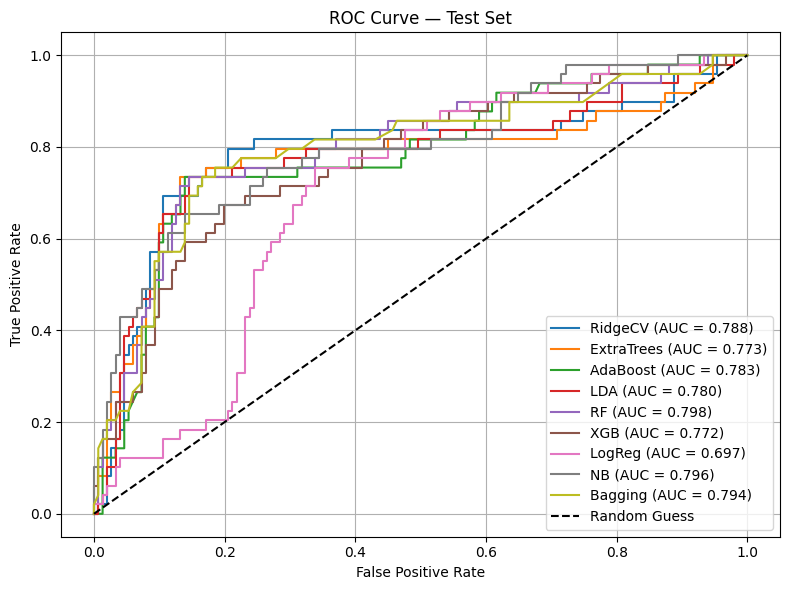

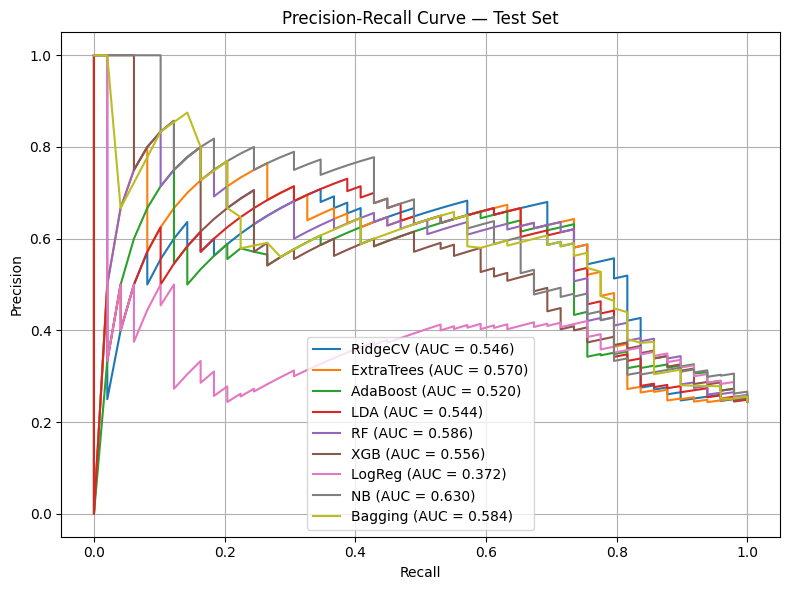

In [32]:
# ============================================================
# step_15 PLOT ROC + PR CURVES — VISUAL COMPARISON
# ============================================================
# Why:
# - Visualize how model performance changes across thresholds.
# - ROC → good for general ranking (TPR vs FPR).
# - PR → better for imbalanced problems like fraud detection (Precision vs Recall).
# - Helps compare top models side-by-side.
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Define shortlisted contenders based on thresholded evaluation
contenders = [
    "RidgeCV",
    "ExtraTrees",
    "AdaBoost",
    "LDA",
    "RF",
    "XGB",
    "LogReg",
    "NB",
    "Bagging"
]

# 1️⃣ Plot ROC curves
plt.figure(figsize=(8, 6))
for name in contenders:
    y_prob = probas[name]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2️⃣ Plot PR curves
plt.figure(figsize=(8, 6))
for name in contenders:
    y_prob = probas[name]
    precision, recall, _ = precision_recall_curve(y_te, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Test Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# ============================================================
# step_16 FEATURE IMPORTANCE — TREE MODELS ONLY
# ============================================================
# Why:
# - Visualize top predictive features per model.
# - Useful for model transparency and understanding domain signals.
# - Only tree-based models support .feature_importances_ directly.
# ============================================================

import numpy as np
import pandas as pd
import plotly.express as px

# 1️⃣ Extract feature names from preprocessor (includes OHE-expanded names)
ohe_feature_names = pipe_rf.named_steps["prep"].named_transformers_["ohe"].get_feature_names_out()
feature_names = num_cols + ord_cols + ohe_feature_names.tolist()

# 2️⃣ Define tree-based models that support feature_importances_
tree_pipes = {
    "Random Forest": pipe_rf,
    "Extra Trees": pipe_extra,
    "AdaBoost": pipe_ada,
    "XGBoost": pipe_xgb
}

# 3️⃣ Top N features to show
N = 40

# 4️⃣ Loop through each model and plot its top features
for model_name, pipe in tree_pipes.items():
    try:
        importances = pipe.named_steps["clf"].feature_importances_
        df_imp = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False).head(N)

        fig = px.bar(
            df_imp.sort_values("importance", ascending=True),
            x="importance", y="feature",
            orientation="h",
            title=f"Top {N} Feature Importances — {model_name}",
            height=800
        )
        fig.update_layout(yaxis_title="Feature", xaxis_title="Importance")
        fig.show()
        
    except AttributeError:
        print(f"⚠️ Model '{model_name}' does not support feature_importances_")



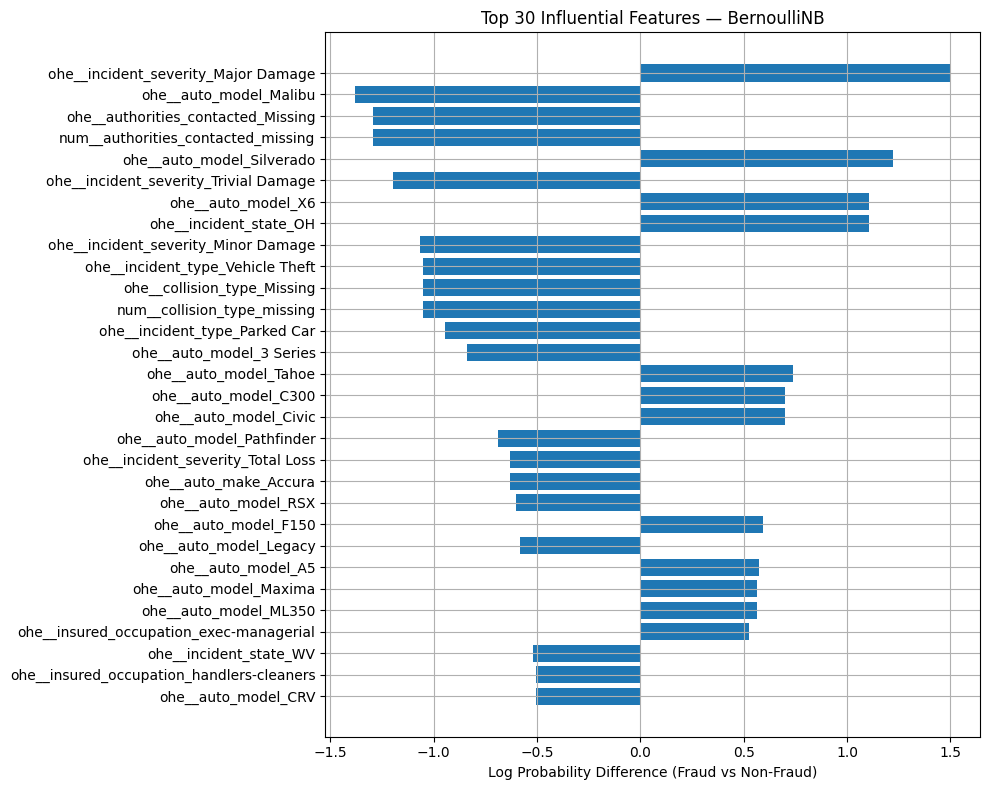

In [34]:
# ============================================================
# Feature Influence — BernoulliNB
# ============================================================
# Shows log probabilities learned by NB per feature per class.
# Works for binary/OHE input; higher abs value = stronger signal.
# ============================================================

import matplotlib.pyplot as plt

# Get feature names from preprocessor
feature_names_nb = pipe_nb.named_steps["prep"].get_feature_names_out()

# Extract log probs (shape: [n_classes, n_features])
log_probs = pipe_nb.named_steps["clf"].feature_log_prob_

# Compute difference between fraud (class 1) and non-fraud (class 0)
delta_log_prob = log_probs[1] - log_probs[0]

# Build DataFrame
df_nb = pd.DataFrame({
    "feature": feature_names_nb,
    "log_prob_diff": delta_log_prob
}).sort_values("log_prob_diff", key=np.abs, ascending=False).head(30)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(df_nb["feature"], df_nb["log_prob_diff"])
plt.xlabel("Log Probability Difference (Fraud vs Non-Fraud)")
plt.title("Top 30 Influential Features — BernoulliNB")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


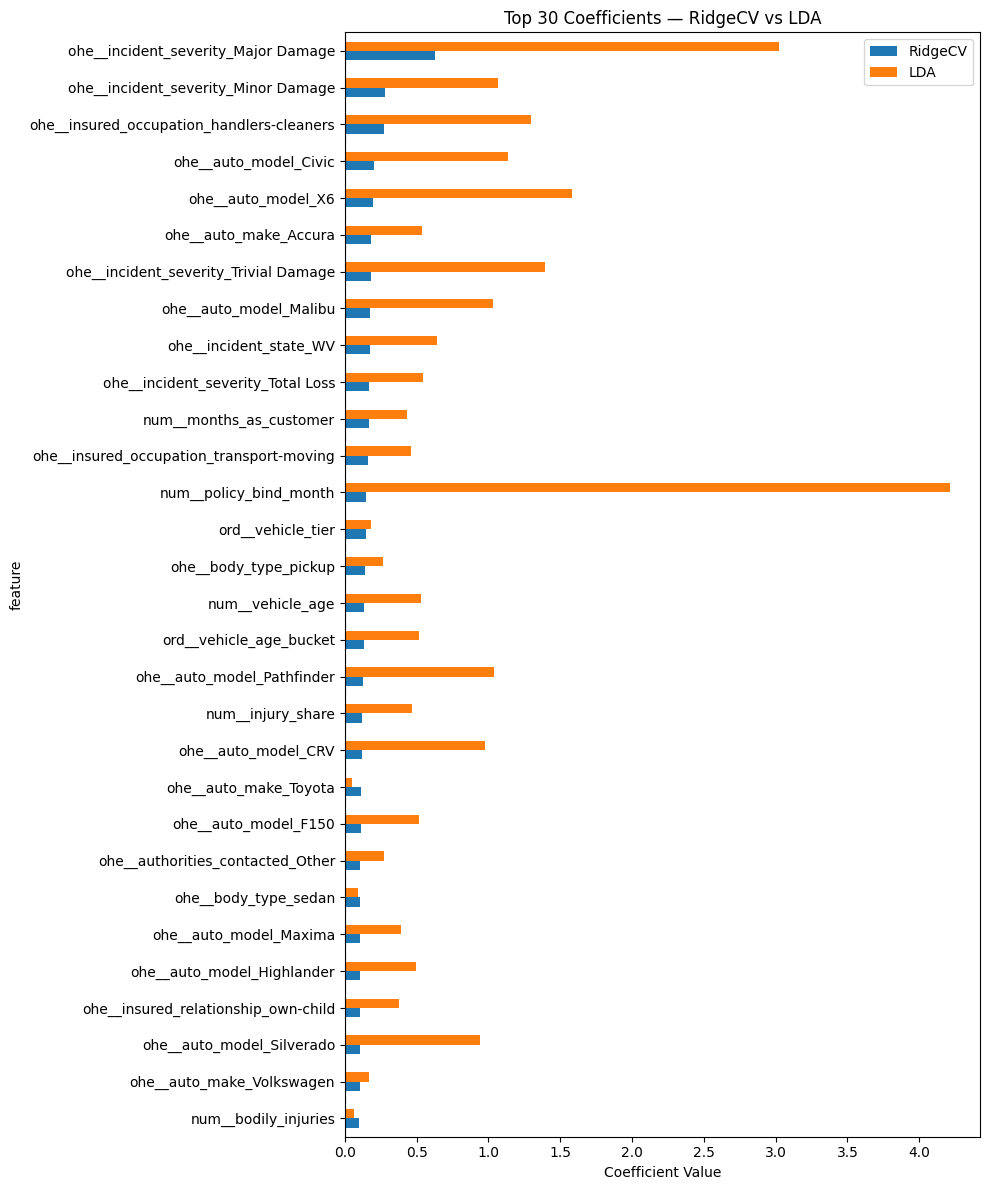

In [41]:
# ============================================================
# Coefficient Visualization — RidgeCV & LDA
# ============================================================
# Shows direction & strength of each feature toward fraud.
# Works best with scaled numeric and OHE categorical inputs.
# ============================================================

# 1️⃣ Shared feature names from preprocessor
feature_names_linear = pipe_ridge.named_steps["prep"].get_feature_names_out()

# 2️⃣ Extract coefficients
# Ridge: get base estimator from calibrated model
ridge_base = pipe_ridge.named_steps["clf"].calibrated_classifiers_[0].estimator
ridge_coef = ridge_base.coef_.flatten()

# LDA: direct access
lda_coef = pipe_lda.named_steps["clf"].coef_.flatten()

# 3️⃣ Combine into DataFrame
df_coefs = pd.DataFrame({
    "feature": feature_names_linear,
    "RidgeCV": ridge_coef,
    "LDA": lda_coef
}).set_index("feature")

# 4️⃣ Sort and plot top features by absolute Ridge importance
top = df_coefs.abs().sort_values("RidgeCV", ascending=False).head(30)
top.sort_values("RidgeCV").plot.barh(
    figsize=(10, 12),
    title="Top 30 Coefficients — RidgeCV vs LDA"
)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()





In [44]:
# ============================================================
# step_17 FEATURE IMPORTANCE — FULL COMPARISON TABLE (ALL MODELS)
# ============================================================
# Why:
# - Compare feature importances or coefficients across multiple models.
# - Includes trees, linear models, calibrated classifiers.
# - Helps identify stable, generalizable predictors across model families.

# 1️⃣ Extract feature names
ohe_feature_names = pipe_rf.named_steps["prep"].named_transformers_["ohe"].get_feature_names_out()
feature_names = num_cols + ord_cols + ohe_feature_names.tolist()

# 2️⃣ Generic helper for importances
def get_model_importance(pipe, attr="feature_importances_"):
    try:
        model = pipe.named_steps["clf"]
        if hasattr(model, attr):
            values = getattr(model, attr)
        elif hasattr(model, "estimator_") and hasattr(model.estimator_, attr):
            values = getattr(model.estimator_, attr)
        else:
            return None

        if isinstance(values, np.ndarray):
            if values.ndim > 1:
                values = values.flatten()
            return pd.Series(values, index=feature_names)
        else:
            return None
    except Exception:
        return None

# 3️⃣ Build importance table
importance_dict = {
    "RandomForest": get_model_importance(pipe_rf, "feature_importances_"),
    "XGBoost":      get_model_importance(pipe_xgb, "feature_importances_"),
    "ExtraTrees":   get_model_importance(pipe_extra, "feature_importances_"),
    "AdaBoost":     get_model_importance(pipe_ada, "feature_importances_"),
    "Bagging":      get_model_importance(pipe_bagging, "feature_importances_"),
    "RidgeCV":      get_model_importance(pipe_ridge, "coef_"),
    "LDA":          get_model_importance(pipe_lda, "coef_"),
    "LogReg":       get_model_importance(pipe_logreg, "coef_"),
    "NB":           None  # Naive Bayes uses log priors, not suitable here
}

# 4️⃣ Combine and sort
df_importance = pd.DataFrame({k: v for k, v in importance_dict.items() if v is not None})
df_importance["mean_abs"] = df_importance.abs().mean(axis=1)
df_sorted = df_importance.sort_values("mean_abs", ascending=False).drop(columns="mean_abs")

# 5️⃣ Output
display(df_sorted.head(30))
df_sorted.to_csv("feature_importance_all_models.csv")


,RandomForest,XGBoost,ExtraTrees,AdaBoost,LDA,LogReg
policy_bind_year,0.02,0.00,0.01,0.00,-51.66,0.00
days_since_bind,0.03,0.00,0.01,0.10,-50.29,-0.00
policy_bind_month,0.02,0.00,0.01,0.05,-4.21,-0.00
incident_severity_Major Damage,0.12,0.03,0.15,0.33,3.02,0.00
policy_bind_quarter,0.01,0.01,0.01,0.00,2.11,-0.00
auto_model_X6,0.00,0.01,0.00,0.00,1.58,0.00
incident_severity_Trivial Damage,0.00,0.00,0.00,0.00,-1.39,-0.00
insured_occupation_handlers-cleaners,0.00,0.01,0.00,0.03,-1.29,-0.00
incident_state_OH,0.00,0.00,0.00,0.00,1.20,0.00
incident_severity_Minor Damage,0.04,0.02,0.05,0.00,-1.06,-0.00


In [42]:
# ============================================================
# 📌 FINAL BASELINE INTERPRETATION — FEATURE SIGNALS & NEXT STEPS
# ============================================================
#
# This section summarizes what we learned from model interpretability
# across Random Forest, Extra Trees, XGBoost, AdaBoost, RidgeCV, LDA, 
# and BernoulliNB. These insights guide how we tune models and how 
# we engineer future features.
#
# ------------------------------------------------------------
# 🔎 1. Universal Fraud Signals (Consistent Across Models)
# ------------------------------------------------------------
# - `incident_severity_Major Damage` is the strongest signal in *every* model.
# - `total_claim_amount`, `days_since_bind`, and `months_as_customer` consistently
#   show up as strong predictors.
# - `collision_type_Missing` is a suspicious feature; XGB and ExtraTrees treat it
#   as one of the most important. This may reflect real-world ambiguity (missing 
#   or inconsistent reporting), not data leakage.
#
# These features are robust: any tuned model will likely lean on them.
#
# ------------------------------------------------------------
# 🌲 2. Tree Ensemble Behavior — RF, Extra Trees, XGB, AdaBoost
# ------------------------------------------------------------
# - RF produces the most *balanced* importance spread, with core signals well
#   distributed across numeric and one-hot encoded features.
# - Extra Trees exaggerates top splits but agrees with RF on ranking.
# - XGB concentrates importance sharply on fewer features, especially sparse OHE 
#   categories (car models, occupations). This can indicate vulnerability to 
#   rare categories.
# - AdaBoost hyper-focuses on top 1–2 features with a steep drop-off, indicating 
#   shallower decision depth.
#
# Ensemble takeaway:
#   RF is the most stable and generalizable.
#   XGB is powerful but may need regularization to avoid overfitting one-hot noise.
#
# ------------------------------------------------------------
# 🧠 3. Linear Models — RidgeCV & LDA
# ------------------------------------------------------------
# - RidgeCV produces smooth, stable coefficients (regularization doing its job).
# - LDA produces much larger coefficients and aggressively favors certain 
#   occupations and car models—good insight, poorer stability.
# - Both agree with trees on severity, policy timing, and premium-level signals.
#
# Linear takeaway:
#   RidgeCV = reliable signal direction.
#   LDA = expressive but noisy.
#
# ------------------------------------------------------------
# 🤖 4. BernoulliNB — Pure Polarity Insight
# ------------------------------------------------------------
# - Highlights log-odds differences for each binary OHE feature.
# - Confirms the same main story: severity, missing collision info, certain car 
#   models.
#
# NB takeaway:
#   Not a production model, but excellent for seeing feature polarity.
#
# ------------------------------------------------------------
# 🧩 5. Cross-Model Consensus Features
# ------------------------------------------------------------
# Strong fraud predictors across models:
#   - incident severity
#   - missing collision details
#   - early lifecycle (days_since_bind, months_as_customer)
#   - high claims and premium size
#   - specific auto models / occupations (needs regularization)
#
# No longer problematic:
#   - insured_hobbies_* (removed) → no longer dominate → confirms leakage fixed.
#
# ------------------------------------------------------------
# 🛠 6. What This Means for Model Tuning
# ------------------------------------------------------------
# - Tree models should be tuned for:
#     * depth and leaf size (avoid over-reliance on rare categories)
#     * class_weight or scale_pos_weight for minority handling
#     * regularization strength (XGB: gamma, lambda; RF/ET: min_samples_leaf)
#
# - XGB in particular may need:
#     * higher min_child_weight
#     * lower max_depth
#     * stronger L1/L2 penalties
#
# - RidgeCV is a good candidate for:
#     * reduced-feature linear benchmark
#     * understanding directional effects before complex model tuning
#
# ------------------------------------------------------------
# 🧪 7. Feature Engineering Opportunities
# ------------------------------------------------------------
# - Combine redundant one-hots (e.g., grouping car models into categories).
# - Smooth sparse categories (frequency encoding or target-mean encoding).
# - Build interaction features:
#       days_since_bind × claim_amount
#       severity × vehicle_age
#       policy_annual_premium × occupation risk buckets
#
# - Investigate “missingness as a signal”:
#     collision_type_missing is highly predictive → probably meaningful.
#
# - Possibly reduce dimensionality:
#     Many one-hot encoded car models and occupations could be collapsed into 
#     fewer interpretable buckets.
#
# ------------------------------------------------------------
# 🎯 Final Baseline Conclusions
# ------------------------------------------------------------
# - RF is the strongest and most stable model on real metrics (F1, recall).
# - XGB is competitive but more volatile and over-focused on sparse categories.
# - LDA and RidgeCV provide directional sanity checks.
# - Model agreement across severities, claim size, customer tenure, and missing 
#   collision info shows the core signal is genuine and robust.
#
# The baseline is now solid. The next stage is hyperparameter tuning and feature
# engineering to push performance further while controlling for overfitting.
# ============================================================
